In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from category_encoders import MEstimateEncoder
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

In [2]:
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Feature Engineering\Target Encoding\data\ames.csv")
df.shape

(2930, 79)

In [3]:
#Check Categorical Columns
df.select_dtypes(['object']).nunique()

MSSubClass       16
MSZoning          7
Street            2
Alley             3
LotShape          4
LandContour       4
Utilities         3
LotConfig         5
LandSlope         3
Neighborhood     28
Condition1        9
Condition2        8
BldgType          5
HouseStyle        8
OverallQual      10
OverallCond       9
RoofStyle         6
RoofMatl          8
Exterior1st      16
Exterior2nd      17
MasVnrType        4
ExterQual         4
ExterCond         5
Foundation        6
BsmtQual          6
BsmtCond          6
BsmtExposure      5
BsmtFinType1      7
BsmtFinType2      7
Heating           6
HeatingQC         5
CentralAir        2
Electrical        6
KitchenQual       5
Functional        8
FireplaceQu       6
GarageType        7
GarageFinish      4
GarageQual        6
GarageCond        6
PavedDrive        3
PoolQC            5
Fence             5
MiscFeature       5
SaleType         10
SaleCondition     6
dtype: int64

Neighborhood has 28 categories.Strong effect on price.

In [4]:
#Avoid Data Leakage
#20% used only to compute encoding
X_encode = df.sample(frac=0.20,random_state=0)
y_encode=X_encode.pop("SalePrice")

#Remaining 80% used for training
X_pretrain=df.drop(X_encode.index)
y_train=X_pretrain.pop("SalePrice")


In [5]:
#Apply M-Estimate Encoding
encoder=MEstimateEncoder(
    cols=['Neighborhood'],
    m=1.0
)
#m is smoothing strength
encoder.fit(X_encode,y_encode)

,verbose,0
,cols,['Neighborhood']
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None
,randomized,False
,sigma,0.05
,m,1.0


In [6]:
#Transform training data
X_train=encoder.transform(X_pretrain,y_train)

In [7]:
#score model
def score_dataset(X,y,model=XGBRegressor()):
    for colname in X.select_dtypes(["category",'object']):
        X[colname], _=X[colname].factorize()

    score=cross_val_score(model,X,y,cv=5,
    scoring='neg_mean_squared_log_error',)
    score=-1*score.mean()
    score=np.sqrt(score)

    return score

In [9]:
score_without=score_dataset(X_pretrain.copy(),y_train)
score_with=score_dataset(X_train.copy(),y_train)
print("Without encoding : ",score_without)
print("With encoding : ",score_with)

Without encoding :  0.14613122331968087
With encoding :  0.14340196127680901


C:\Users\Acer\AppData\Local\Temp\ipykernel_10872\422009558.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train,kde=True,hist=False)
C:\Users\Acer\AppData\Local\Temp\ipykernel_10872\422009558.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[feature],hist=True,kde=False

<Axes: xlabel='SalePrice', ylabel='Density'>

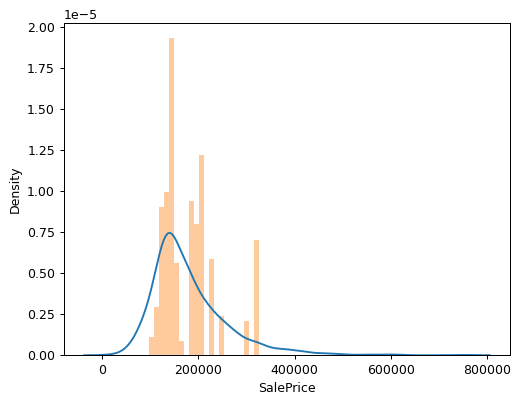

In [11]:
#Visualize Encoding Effect
feature=encoder.cols
plt.figure(dpi=90)
sns.distplot(y_train,kde=True,hist=False)
sns.distplot(X_train[feature],hist=True,kde=False,norm_hist=True)
